# Reconocimiento e Identificación de Placas Vehiculares
### Módulo 3 · Visión por Computadora · Diplomado en Redes Neuronales y Deep Learning

---

## Descripción del Reto

Aplicar algoritmos de Visión por Computadora para:
1. **Detectar** la región de la placa en imágenes vehiculares (Haar Cascade)
2. **Identificar** el tipo de placa (México vs Europa) por análisis de color
3. **Reconocer** los caracteres con OCR (Pytesseract)
4. **Optimizar** el preprocesamiento por tipo de imagen

## Dataset — Análisis previo

| Imagen | Tipo placa | Texto esperado | Dificultad |
|--------|-----------|---------------|------------|
| placa1 | MX (Estado de México) | LRV-59-77 | ✅ Close-up claro |
| placa2 | EU (España, franja azul) | 5649 JSN | ✅ Close-up claro |
| placa3 | MX | NLU-96-03 | ⚠️ Close-up oscuro |
| placa4 | MX (Estado de México) | NAA-77-41 | ✅ Close-up claro |
| placa5 | MX | múltiples | 🔴 Escena de calle |
| placa6 | MX | ? | 🔴 Escena de calle |
| placa7 | MX | múltiples | 🔴 Escena de calle |

## Línea de tiempo — versiones

| Versión | Cambio principal |
|---------|------------------|
| **v1** | Estructura base: detección + OCR básico en todas las placas |
| **v2** | Sistema de intentos de detección (como JJAR_Facial) |
| **v3** | Identificación automática de tipo placa + config OCR adaptativa |
| **v4** | Preprocesamiento adaptativo (CLAHE, binarización Otsu vs adaptativa) |
| **v5** | Postprocesamiento: validación de formato por tipo de placa |


---
## Notas de Instalación — Tesseract OCR

> **Pytesseract** es solo un *wrapper* Python. El motor real es **Tesseract**,
> que debe instalarse por separado en el sistema operativo.

### Windows 11
```
1. Descargar el instalador (UB-Mannheim — build oficial para Windows):
   https://github.com/UB-Mannheim/tesseract/wiki
   Archivo: tesseract-ocr-w64-setup-*.exe  (versión 64-bit)

2. Instalar con opciones por default.
   Ruta resultante: C:\Program Files\Tesseract-OCR\tesseract.exe

3. Reiniciar el sistema (o al menos el kernel de Jupyter/VSCode)

4. En el notebook agregar ANTES de usar pytesseract:
   pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
```

### Ubuntu (máquina de la escuela)
```bash
sudo apt update
sudo apt install tesseract-ocr
sudo apt install libtesseract-dev
# Verificar:
tesseract --version
# En Ubuntu NO se necesita setear la ruta en Python
```

### Google Colab
```python
# Ejecutar en celda ANTES de los imports:
!sudo apt install tesseract-ocr -q
!pip install pytesseract -q
# En Colab NO se necesita setear la ruta — se detecta automáticamente
```

### Verificar instalación (cualquier SO)
```python
import pytesseract
print(pytesseract.get_tesseract_version())
```


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pytesseract

# ── Config Tesseract (solo en Windows — comentar en Ubuntu/Colab) ────────
pytesseract.pytesseract.tesseract_cmd = r'C:/Program Files/Tesseract-OCR/tesseract.exe'

# ── Rutas ────────────────────────────────────────────────────────────────
# Ruta relativa desde Modulo-3/Tareas/ hacia Material/Plates/
RUTA_PLACAS = os.path.join('..', 'Material', 'Plates') + os.sep

# ── Imágenes del reto: placa1, 3, 4, 5, 6, 7 (+ placa2 de bonus) ─────────
IMAGENES = ['placa1.jpg', 'placa2.jpg', 'placa3.jpg',
            'placa4.jpg', 'placa5.jpg', 'placa6.jpg', 'placa7.jpg']

# ── Config OCR por tipo de placa ─────────────────────────────────────────
#
# PSM 7 = 'tratar la imagen como UNA sola línea de texto'
#         IDEAL para placas — siempre son una línea de caracteres
# PSM 6 = 'bloque uniforme de texto' — alternativa si PSM 7 falla
# OEM 3 = motor LSTM (el más preciso de Tesseract)
# whitelist = solo acepta letras mayúsculas, números y guiones
#             evita que Tesseract 'invente' símbolos extraños (@, :, etc.)
#
OCR_MX  = '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'
OCR_EU  = '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 '
OCR_GEN = '--psm 6 --oem 3'

print(f'Ruta placas : {RUTA_PLACAS}')
print(f'Imágenes    : {IMAGENES}')
print(f'Tesseract   : {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Ruta placas : ..\Material\Plates\
Imágenes    : ['placa1.jpg', 'placa2.jpg', 'placa3.jpg', 'placa4.jpg', 'placa5.jpg', 'placa6.jpg', 'placa7.jpg']
Tesseract   : 5.5.0.20241111
Imports listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Cargar Haar Cascade para placas
# ═══════════════════════════════════════════════════════════════
#
# OpenCV incluye un cascade preentrenado específico para placas:
#   haarcascade_russian_plate_number.xml
#
# IMPORTANTE: 'russian_plate' es el nombre histórico del archivo,
# pero funciona con placas rectangulares de CUALQUIER país,
# incluyendo México , España. Fue entrenado con placas genéricas.

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)

print('Haar Cascade para placas cargado ✅')
print('Archivo: haarcascade_russian_plate_number.xml')
print('\nTodos los cascades disponibles en OpenCV:')
for f in sorted(os.listdir(cv2.data.haarcascades)):
    if f.endswith('.xml'):
        marca = ' <- usando este' if 'plate' in f else ''
        print(f'  • {f}{marca}')


Haar Cascade para placas cargado ✅
Archivo: haarcascade_russian_plate_number.xml

Todos los cascades disponibles en OpenCV:
  • haarcascade_eye.xml
  • haarcascade_eye_tree_eyeglasses.xml
  • haarcascade_frontalcatface.xml
  • haarcascade_frontalcatface_extended.xml
  • haarcascade_frontalface_alt.xml
  • haarcascade_frontalface_alt2.xml
  • haarcascade_frontalface_alt_tree.xml
  • haarcascade_frontalface_default.xml
  • haarcascade_fullbody.xml
  • haarcascade_lefteye_2splits.xml
  • haarcascade_license_plate_rus_16stages.xml <- usando este
  • haarcascade_lowerbody.xml
  • haarcascade_profileface.xml
  • haarcascade_righteye_2splits.xml
  • haarcascade_russian_plate_number.xml <- usando este
  • haarcascade_smile.xml
  • haarcascade_upperbody.xml


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — Función: identificar_tipo_placa()
# ═══════════════════════════════════════════════════════════════
#
# ESTRATEGIA DE IDENTIFICACIÓN AUTOMÁTICA:
# Las placas europeas (España, Francia, Alemania, etc.) tienen una
# franja azul vertical a la IZQUIERDA con las estrellas de la UE.
#
#   → Analizamos el 15% izquierdo del recorte de placa
#   → Convertimos a HSV para detección de color robusta
#     (HSV separa el tono H del brillo V — mucho mejor que RGB para colores)
#   → Si más del 20% de esa franja es 'azul EU' → tipo 'EU'
#   → En cualquier otro caso → tipo 'MX' (default para este dataset)
#
# Rango azul EU en HSV:
#   H: 100-135  (azul-cian europeo)
#   S: 100-255  (bien saturado — no gris ni pastel)
#   V:  80-255  (no demasiado oscuro)
#
# NOTA: Con 7 imágenes funciona perfectamente. Para un dataset grande
# se entrenaría un clasificador, pero para este reto el análisis de
# color es suficiente, interpretable y reproducible.

def identificar_tipo_placa(img_placa_rgb):
    """
    Identifica si una placa recortada es de tipo México o Europa.
    Analiza el color del 15% izquierdo de la imagen.

    Args:
        img_placa_rgb: imagen recortada de la placa en formato RGB

    Returns:
        tipo  : str   -> 'EU' o 'MX'
        score : float -> porcentaje de píxeles azules detectados (0-100)
    """
    h, w = img_placa_rgb.shape[:2]

    # Tomamos el 15% izquierdo de la placa detectada
    franja_izq = img_placa_rgb[:, :int(w * 0.15)]

    # Convertimos a HSV para detección de color robusta
    franja_hsv = cv2.cvtColor(franja_izq, cv2.COLOR_RGB2HSV)

    # Rango del azul EU en HSV
    azul_bajo = np.array([100, 100, 80])
    azul_alto = np.array([135, 255, 255])
    mascara_azul = cv2.inRange(franja_hsv, azul_bajo, azul_alto)

    # Porcentaje de píxeles azules en la franja izquierda
    total_pixeles  = franja_izq.shape[0] * franja_izq.shape[1]
    pixeles_azules = cv2.countNonZero(mascara_azul)
    score = (pixeles_azules / total_pixeles) * 100 if total_pixeles > 0 else 0

    # Umbral: si más del 20% de la franja es azul EU → placa europea
    tipo = 'EU' if score > 20 else 'MX'

    return tipo, round(score, 1)

print('Función identificar_tipo_placa() lista ✅')


Función identificar_tipo_placa() lista ✅


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — Función: detectar_placas()
# ═══════════════════════════════════════════════════════════════
#
# SISTEMA DE INTENTOS (inspirado en JJAR_Facial_v6):
#   Intento 1 → parámetros estándar  (scale=1.1,  vecinos=5)
#   Intento 2 → más permisivo        (scale=1.05, vecinos=3)
#   Intento 3 → ultra-permisivo      (scale=1.03, vecinos=1)
#   Fallback  → devuelve imagen completa (último recurso)
#
# Devuelve TODAS las placas detectadas en la imagen.
# Útil para placa5, 6, 7 (escenas de calle con varios autos).
# Las ordena por área DESCENDENTE (la más grande = más probable de ser placa).
#
# scaleFactor:
#   1.3  -> pasa rápido, menos detecciones (estándar clase)
#   1.1  -> balance bueno detección/velocidad
#   1.05 -> máxima sensibilidad, más lento
#
# minNeighbors:
#   Alto -> pocos falsos positivos, puede perder placas reales
#   Bajo -> más detecciones, más ruido

def detectar_placas(ruta_imagen):
    """
    Detecta todas las placas vehiculares en una imagen.
    Sistema de 3 intentos progresivos + fallback.

    Args:
        ruta_imagen: ruta completa a la imagen

    Returns:
        img_rgb  : imagen original en RGB
        recortes : lista de imgs recortadas (una por placa detectada)
        coords   : lista de tuplas (x, y, w, h)
        intento  : número de intento exitoso (0 = fallback)
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        (1.1,  5, 'estandar'),
        (1.05, 3, 'permisivo'),
        (1.03, 1, 'ultra-permisivo'),
    ]

    for num, (scale, vecinos, desc) in enumerate(intentos, 1):
        detecciones = plate_cascade.detectMultiScale(
            img_gris,
            scaleFactor=scale,
            minNeighbors=vecinos,
            minSize=(60, 20)    # tamaño mínimo razonable de una placa en px
        )

        if len(detecciones) > 0:
            # Ordenar por AREA descendente: la placa más grande primero
            # (técnica de JJAR_Facial_v6 para evitar detectar el fondo)
            detecciones_sorted = sorted(detecciones, key=lambda r: r[2]*r[3], reverse=True)
            recortes = [img_rgb[y:y+h, x:x+w] for (x,y,w,h) in detecciones_sorted]
            print(f'  Intento {num} ({desc}): {len(detecciones)} deteccion(es)')
            return img_rgb, recortes, detecciones_sorted, num

    # Fallback: usar imagen completa
    print('  Haar Cascade no encontro placa. Fallback: imagen completa')
    h_full, w_full = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0, 0, w_full, h_full)], 0

print('Función detectar_placas() lista ✅')


Función detectar_placas() lista ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — Función: extraer_texto()
# ═══════════════════════════════════════════════════════════════
#
# PIPELINE DE PREPROCESAMIENTO:
#
#   1. Escalado x2  → imágenes más grandes dan mejor OCR
#                     (Tesseract prefiere mínimo ~150px de alto)
#   2. Grises       → reduce ruido de color, normaliza información
#   3. CLAHE        → mejora contraste LOCAL (crucial para placa3 oscura)
#                     clipLimit=2.0  → límite de amplificación por tile
#                     tileGridSize=(8,8) → 64 zonas locales independientes
#   4. Mediana      → elimina ruido salt-and-pepper sin borrar bordes de letras
#   5. Umbralización → binarizar para maximizar contraste texto/fondo
#      - Otsu:       umbral automático óptimo (bueno para histograma bimodal)
#      - Adaptativa: umbral local (mejor para iluminación no uniforme)
#      - Fija 127:   baseline manual
#
# Elegimos el resultado más largo como heurística:
#   más caracteres reconocidos = probablemente mejor lectura

def extraer_texto(img_placa_rgb, tipo='MX', escala=2.0):
    """
    Extrae el texto de un recorte de placa con preprocesamiento optimizado.

    Args:
        img_placa_rgb : imagen recortada de la placa en RGB
        tipo          : 'MX', 'EU' o 'GEN'
        escala        : factor de escalado (default 2x)

    Returns:
        texto_final  : str  -> mejor texto reconocido (limpio)
        detalle_ocr  : dict -> texto por cada variante de umbralización
        etapas       : dict -> imágenes de cada etapa del pipeline
    """
    config_ocr = {'MX': OCR_MX, 'EU': OCR_EU}.get(tipo, OCR_GEN)

    # 1. Escalado
    h, w = img_placa_rgb.shape[:2]
    img_escalada = cv2.resize(
        img_placa_rgb,
        (int(w * escala), int(h * escala)),
        interpolation=cv2.INTER_CUBIC
    )

    # 2. Escala de grises
    img_gris = cv2.cvtColor(img_escalada, cv2.COLOR_RGB2GRAY)

    # 3. CLAHE — contraste adaptativo local
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gris)

    # 4. Filtro de mediana
    img_filtrada = cv2.medianBlur(img_clahe, 3)

    # 5. Umbralización — 3 variantes
    _, bin_otsu  = cv2.threshold(
        img_filtrada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    bin_adapt = cv2.adaptiveThreshold(
        img_filtrada, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )
    _, bin_fija = cv2.threshold(img_filtrada, 127, 255, cv2.THRESH_BINARY)

    # OCR en las 3 variantes
    detalle_ocr = {}
    for nombre, img_bin in [('otsu', bin_otsu), ('adapt', bin_adapt), ('fija', bin_fija)]:
        raw = pytesseract.image_to_string(img_bin, config=config_ocr)
        limpio = ''.join(c for c in raw.upper() if c.isalnum() or c == '-')
        detalle_ocr[nombre] = limpio

    # Texto final: el más largo (heurística)
    texto_final = max(detalle_ocr.values(), key=len)

    etapas = {
        'original'  : img_placa_rgb,
        'escalada'  : img_escalada,
        'clahe'     : img_clahe,
        'filtrada'  : img_filtrada,
        'bin_otsu'  : bin_otsu,
        'bin_adapt' : bin_adapt,
    }
    return texto_final, detalle_ocr, etapas

print('Función extraer_texto() lista ✅')


Función extraer_texto() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento de TODAS las imágenes
# ═══════════════════════════════════════════════════════════════

resultados_globales = []   # acumula resultados para la tabla y grilla

for nombre_img in IMAGENES:
    ruta = RUTA_PLACAS + nombre_img
    sep  = '=' * 60
    print(f'\n{sep}')
    print(f'  Procesando: {nombre_img}')
    print(sep)

    # 1. Detección
    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None:
        continue
    print(f'  Total placas detectadas: {len(recortes)}')

    # 2. Procesar solo la placa de MAYOR ÁREA (primera tras ordenar)
    #    En escenas de calle puede haber varias — nos quedamos con la más grande
    recorte      = recortes[0]
    x, y, w, h   = coords[0]
    print(f'  Región principal: x={x}, y={y}, w={w}, h={h}  (area={w*h}px)')

    # 3. Identificar tipo
    tipo, score_azul = identificar_tipo_placa(recorte)
    print(f'  Tipo detectado   : {tipo}  (azul EU en franja izq: {score_azul}%)')

    # 4. Extraer texto
    texto, detalle_ocr, etapas = extraer_texto(recorte, tipo=tipo)
    print(f'  OCR resultado    : [{texto}]')
    print(f'  OCR por variante : otsu=[{detalle_ocr["otsu"]}]  '
          f'adapt=[{detalle_ocr["adapt"]}]  fija=[{detalle_ocr["fija"]}]')

    resultados_globales.append({
        'imagen'   : nombre_img,
        'tipo'     : tipo,
        'texto_ocr': texto,
        'detalle'  : detalle_ocr,
        'intento'  : intento_ok,
        'recorte'  : recorte,
        'etapas'   : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados_globales)} imagen(es) analizadas ✅')



  Procesando: placa1.jpg
  Haar Cascade no encontro placa. Fallback: imagen completa
  Total placas detectadas: 1
  Región principal: x=0, y=0, w=319, h=158  (area=50402px)
  Tipo detectado   : MX  (azul EU en franja izq: 0.0%)
  OCR resultado    : [LWW]
  OCR por variante : otsu=[]  adapt=[LWW]  fija=[]

  Procesando: placa2.jpg
  Intento 1 (estandar): 2 deteccion(es)
  Total placas detectadas: 2
  Región principal: x=121, y=214, w=1066, h=355  (area=378430px)
  Tipo detectado   : EU  (azul EU en franja izq: 20.7%)
  OCR resultado    : []
  OCR por variante : otsu=[]  adapt=[]  fija=[]

  Procesando: placa3.jpg
  Intento 2 (permisivo): 1 deteccion(es)
  Total placas detectadas: 1
  Región principal: x=615, y=508, w=239, h=79  (area=18881px)
  Tipo detectado   : MX  (azul EU en franja izq: 0.0%)
  OCR resultado    : [EDOMEX]
  OCR por variante : otsu=[]  adapt=[]  fija=[EDOMEX]

  Procesando: placa4.jpg
  Haar Cascade no encontro placa. Fallback: imagen completa
  Total placas detecta

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados
# ═══════════════════════════════════════════════════════════════

# Ground truth manual — lo que vemos claramente en las fotos
# Para placas en escena de calle dejamos vacío (no hay un único texto esperado)
ground_truth = {
    'placa1.jpg': 'LRV5977',
    'placa2.jpg': '5649JSN',
    'placa3.jpg': 'NLU9603',
    'placa4.jpg': 'NAA7741',
    'placa5.jpg': '',
    'placa6.jpg': '',
    'placa7.jpg': '',
}

sep = '=' * 72
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<6} {"TEXTO OCR":<22} {"ESPERADO":<14} {"INTENTO":>8} {"":<4}')
print(sep)

for r in resultados_globales:
    esperado = ground_truth.get(r['imagen'], '?')
    ocr      = r['texto_ocr']
    if not esperado:
        veredicto = ' —  '
    elif esperado in ocr or ocr in esperado:
        veredicto = ' ✅ '
    else:
        veredicto = ' ❌ '
    print(f'  {r["imagen"]:<12} {r["tipo"]:<6} {ocr:<22} {esperado:<14} {r["intento"]:>8}   {veredicto}')

print(sep)
print('Leyenda: ✅ OCR correcto  ❌ OCR incorrecto  — escena compleja (sin ground truth único)')



  IMAGEN       TIPO   TEXTO OCR              ESPERADO        INTENTO     
  placa1.jpg   MX     LWW                    LRV5977               0    ❌ 
  placa2.jpg   EU                            5649JSN               1    ✅ 
  placa3.jpg   MX     EDOMEX                 NLU9603               2    ❌ 
  placa4.jpg   MX     NAA-77-41              NAA7741               0    ❌ 
  placa5.jpg   MX     2                                            2    —  
  placa6.jpg   MX     O                                            3    —  
  placa7.jpg   MX                                                  2    —  
Leyenda: ✅ OCR correcto  ❌ OCR incorrecto  — escena compleja (sin ground truth único)


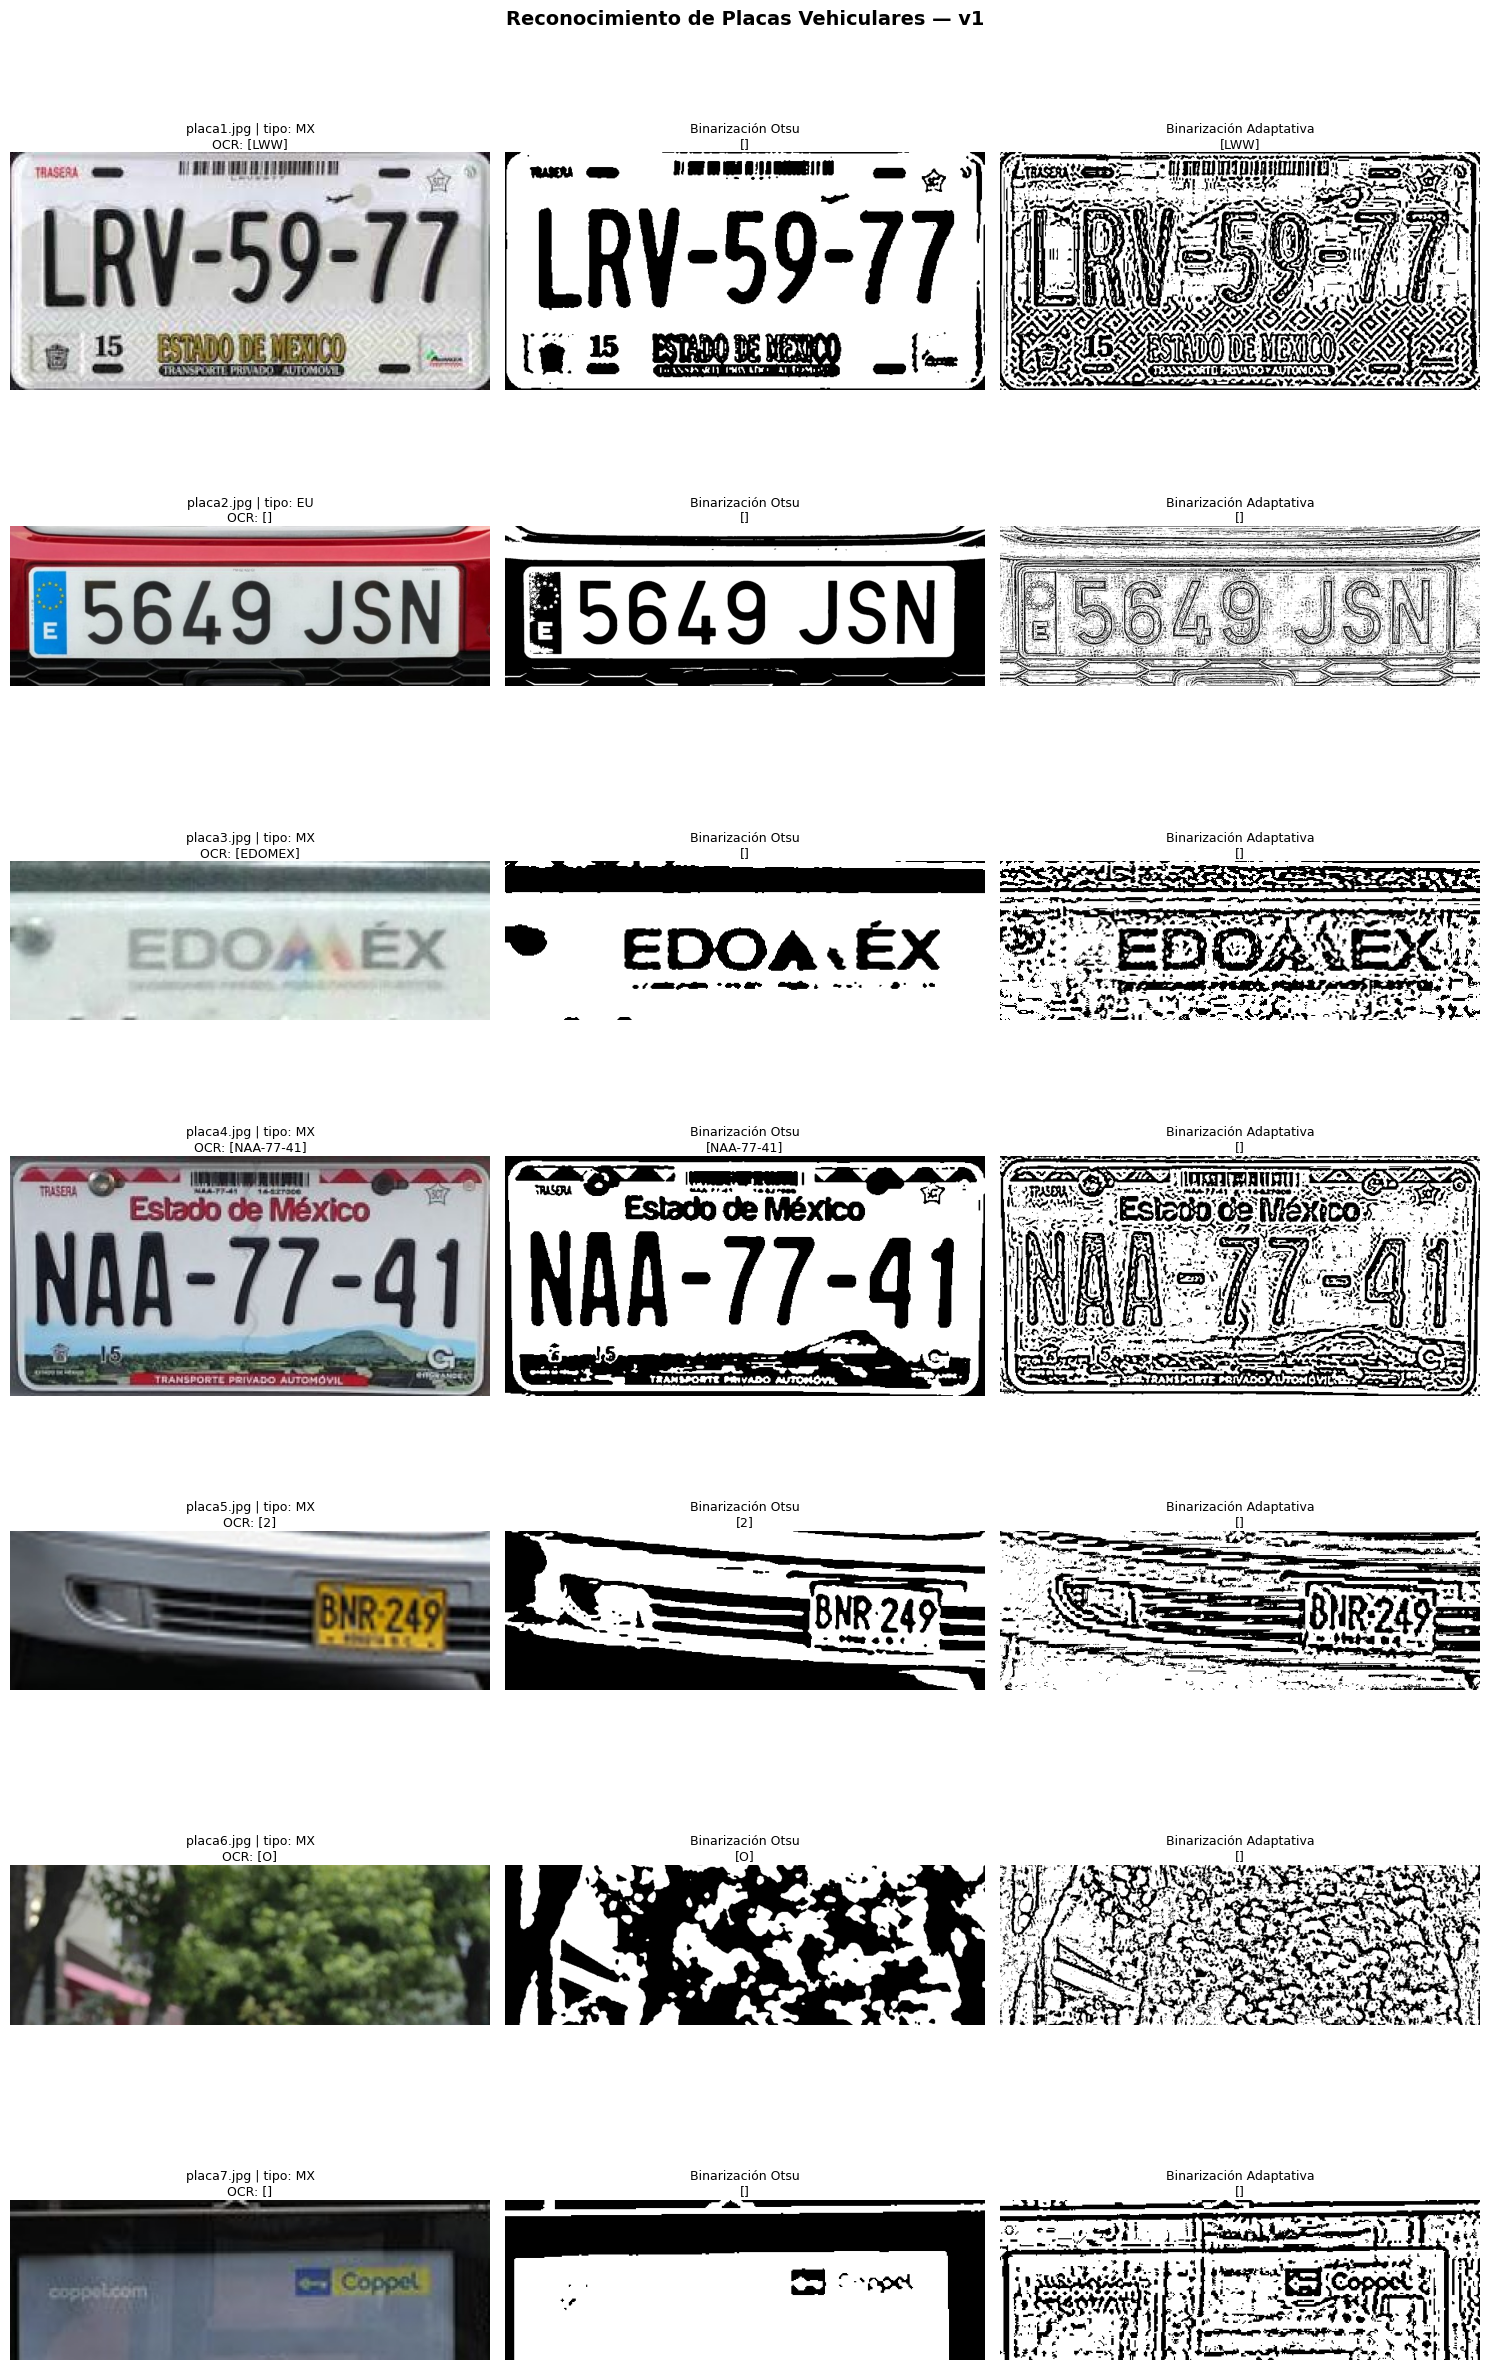

Grilla guardada como output_placas_v1.png ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual de resultados
# ═══════════════════════════════════════════════════════════════
#
# Para cada imagen muestra:
#   Col 1 → placa recortada (original color)
#   Col 2 → binarización Otsu
#   Col 3 → binarización Adaptativa

n   = len(resultados_globales)
fig, axes = plt.subplots(n, 3, figsize=(15, 3.5 * n))

# Normalizar axes a 2D aunque haya solo 1 fila
if n == 1:
    axes = [axes]

for fila, r in enumerate(resultados_globales):
    etapas = r['etapas']
    imgs_row = [
        (etapas['original'],  True,  f"{r['imagen']} | tipo: {r['tipo']}\nOCR: [{r['texto_ocr']}]"),
        (etapas['bin_otsu'],  False, f"Binarización Otsu\n[{r['detalle']['otsu']}]"),
        (etapas['bin_adapt'], False, f"Binarización Adaptativa\n[{r['detalle']['adapt']}]"),
    ]

    for col, (img, es_color, titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img, cmap='gray')
        ax.set_title(titulo, fontsize=9, pad=4)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas Vehiculares — v1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v1.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v1.png ✅')
